# **Going for Gold: Determining Which Attributes Predict Olympic Medals**

Austin Domer, Hanan Ali, and Peyton Hansen

## **Data Loading**

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import MultinomialNB


In [72]:
data = pd.read_csv("./dataset_olympics.csv")
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


## **Data Cleaning**

In [74]:
data.duplicated().sum()

data.drop_duplicates(inplace = True)

data.duplicated().sum()

print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 32.9+ MB
None


In [75]:
data = data[data['Year'] >= 1980]
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 157417 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      157417 non-null  int64  
 1   Name    157417 non-null  object 
 2   Sex     157417 non-null  object 
 3   Age     156845 non-null  float64
 4   Height  149270 non-null  float64
 5   Weight  148827 non-null  float64
 6   Team    157417 non-null  object 
 7   NOC     157417 non-null  object 
 8   Games   157417 non-null  object 
 9   Year    157417 non-null  int64  
 10  Season  157417 non-null  object 
 11  City    157417 non-null  object 
 12  Sport   157417 non-null  object 
 13  Event   157417 non-null  object 
 14  Medal   21926 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 19.2+ MB
None


In [76]:
hyphen = data['Team'].str.contains('-', na=False)
data = data[~hyphen]
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 154052 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      154052 non-null  int64  
 1   Name    154052 non-null  object 
 2   Sex     154052 non-null  object 
 3   Age     153488 non-null  float64
 4   Height  146108 non-null  float64
 5   Weight  145710 non-null  float64
 6   Team    154052 non-null  object 
 7   NOC     154052 non-null  object 
 8   Games   154052 non-null  object 
 9   Year    154052 non-null  int64  
 10  Season  154052 non-null  object 
 11  City    154052 non-null  object 
 12  Sport   154052 non-null  object 
 13  Event   154052 non-null  object 
 14  Medal   21266 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 18.8+ MB
None


In [77]:
data=data.drop(['ID', 'Name','Games', 'Year','Season', 'Sport', 'NOC','City','Event'], axis=1)

In [78]:
# Check null values in the dataset
print(data.isna().mean())

data = data.dropna(subset=['Age','Height','Weight'])

print(data.isna().mean())

Sex       0.000000
Age       0.003661
Height    0.051567
Weight    0.054151
Team      0.000000
Medal     0.861956
dtype: float64
Sex       0.000000
Age       0.000000
Height    0.000000
Weight    0.000000
Team      0.000000
Medal     0.856442
dtype: float64


# **Dropped Attribute Exploratory Analysis**

In [79]:
# Team summary
data['Team'].value_counts()

,count
Team,
United States,8712
Canada,5715
France,5482
Germany,5412
Italy,5407
...,...
Salinero,1
Satchmo,1
Solos Carex,1


**Gold Medals**

In [80]:
# Countries with most Gold medals
gold_countries = data[(data.Medal == 'Gold')].Team
gold_countries = gold_countries.value_counts().head(20)
gold_countries

,count
Team,
United States,1245
Germany,424
Soviet Union,390
Russia,356
China,308
Canada,302
Australia,260
Great Britain,231
East Germany,218


In [81]:
#Gold medalist DataFrame
goldMedals = data[(data.Medal == 'Gold')]
goldMedals.head()

,Sex,Age,Height,Weight,Team,Medal
60,M,20.0,176.0,85.0,Norway,Gold
73,M,30.0,176.0,85.0,Norway,Gold
76,M,30.0,176.0,85.0,Norway,Gold
78,M,34.0,176.0,85.0,Norway,Gold
172,M,28.0,180.0,83.0,Belarus,Gold


# **Kept Attribute Exploratory Analysis**

**Correlation between Medals and other features (Age, Weight, and Height)**

The correlation between Age and Medal is: nan


/tmp/ipykernel_7049/3424072121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Age', data=data, palette='Set3')


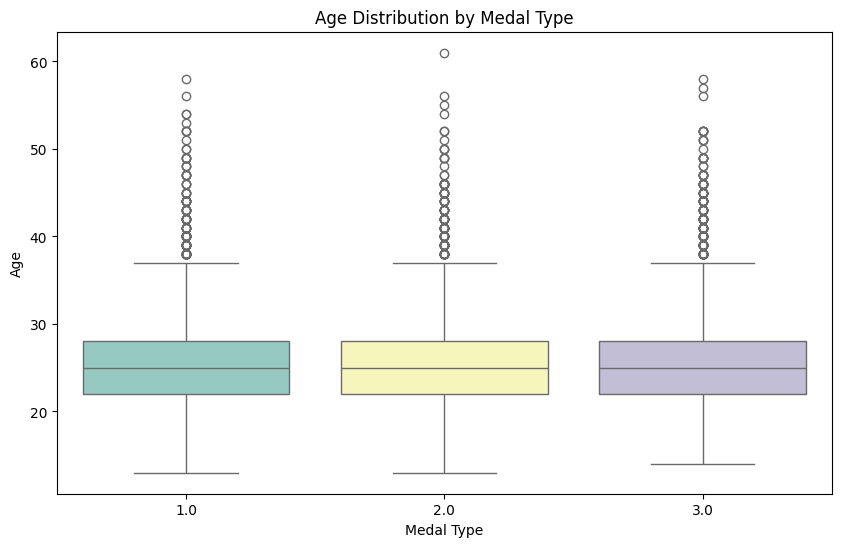

The correlation between Weight and Medal is: nan


/tmp/ipykernel_7049/3424072121.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Weight', data=data, palette='Set3')


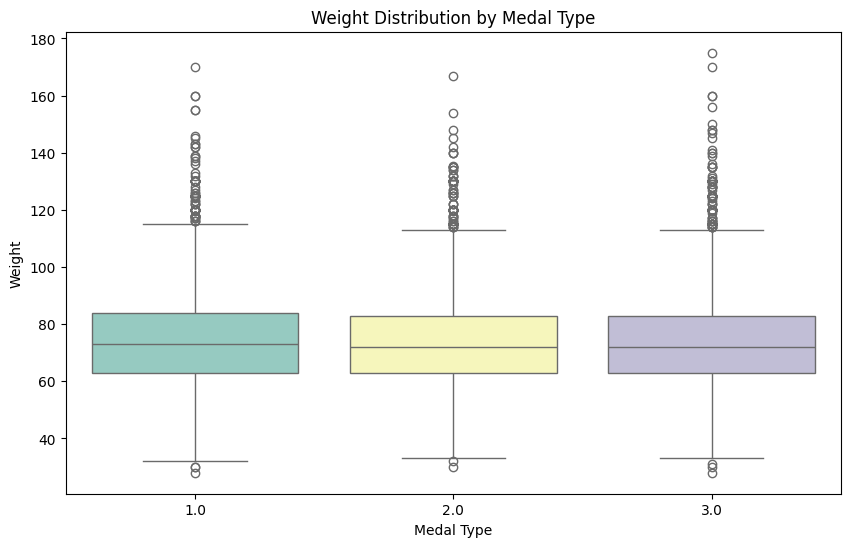

The correlation between Height and Medal is: nan


/tmp/ipykernel_7049/3424072121.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Height', data=data, palette='Set3')


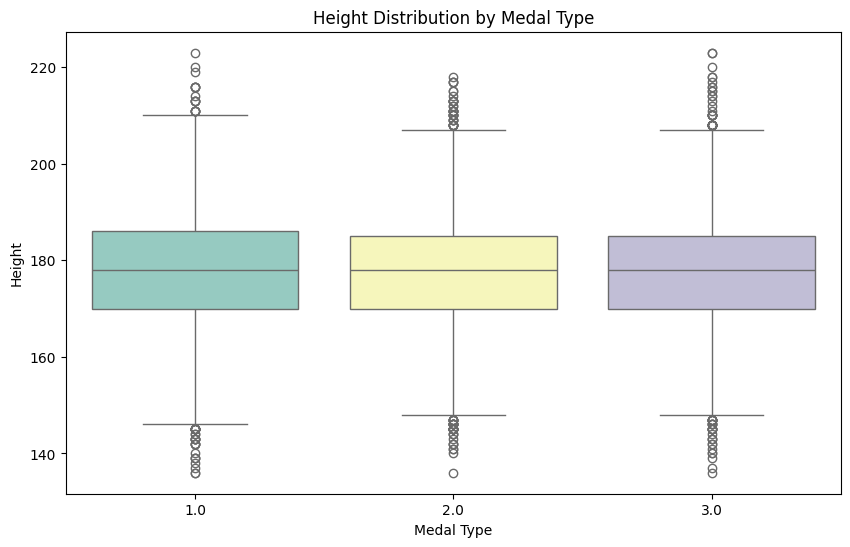

In [82]:
# Correlation of numerical features and Medals
medal_mapping = {'Gold': 1, 'Silver': 2, 'Bronze': 3, '': 0}
data['Medal'] = data['Medal'].map(medal_mapping)

# Calculate the correlation between Age and Medal
age = data['Age'].corr(data['Medal'].map(medal_mapping))

print(f"The correlation between Age and Medal is: {age}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Medal', y='Age', data=data, palette='Set3')
plt.title('Age Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Age')
plt.show()

# Calculate the correlation between Weight and Medal
weight = data['Weight'].corr(data['Medal'].map(medal_mapping))

print(f"The correlation between Weight and Medal is: {weight}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Medal', y='Weight', data=data, palette='Set3')
plt.title('Weight Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Weight')
plt.show()

# Calculate the correlation between Height and Medal
height = data['Height'].corr(data['Medal'].map(medal_mapping))

print(f"The correlation between Height and Medal is: {height}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Medal', y='Height', data=data, palette='Set3')
plt.title('Height Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Height')
plt.show()

In [83]:
# Change Medal type
data['Medal'] = data['Medal'].astype(str)

In [84]:
# Medal column in binary
data['Medal'] = data['Medal'].apply(lambda x: 1 if str(x) != 'nan' else 0)
data.head(35)

,Sex,Age,Height,Weight,Team,Medal
0,M,24.0,180.0,80.0,China,0
1,M,23.0,170.0,60.0,China,0
4,F,21.0,185.0,82.0,Netherlands,0
5,F,21.0,185.0,82.0,Netherlands,0
6,F,25.0,185.0,82.0,Netherlands,0
7,F,25.0,185.0,82.0,Netherlands,0
8,F,27.0,185.0,82.0,Netherlands,0
9,F,27.0,185.0,82.0,Netherlands,0
10,M,31.0,188.0,75.0,United States,0
11,M,31.0,188.0,75.0,United States,0


**Distribution of Sex**

In [85]:
# Participants' gender distribution
genders = data.Sex.value_counts()
genders

,count
Sex,
M,90747
F,54219


**Top Teams with Medals**

In [86]:
# Top 15 participating countries
top_countries = data.Team.value_counts().sort_values(ascending=False).head(15)
top_countries

,count
Team,
United States,8712
Canada,5715
France,5482
Germany,5412
Italy,5407
Japan,5013
Great Britain,5001
Australia,4919
China,4699


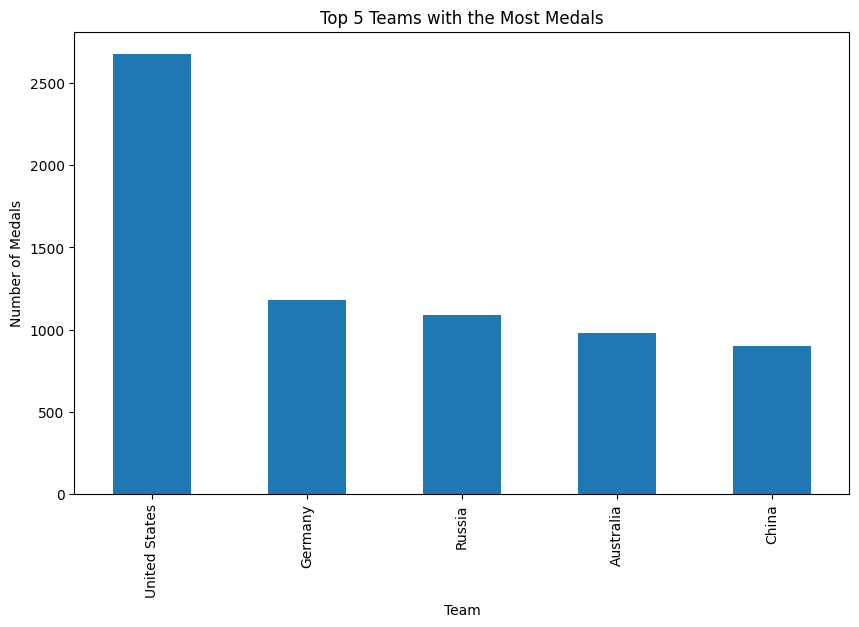

In [87]:
Medalists = data[data['Medal'] == 1]
#Top 5 countries
gold_counts = Medalists['Team'].value_counts().nlargest(5)
# print(gold_counts)
plt.figure(figsize=(10, 6))
gold_counts.plot(kind='bar')
plt.title('Top 5 Teams with the Most Medals')
plt.xlabel('Team')
plt.ylabel('Number of Medals')
plt.show()

In [88]:
#Age distribution of participants
age_groups = data.Age.value_counts().sort_values(ascending=False).head(15)
age_groups


,count
Age,
23.0,12451
24.0,12371
22.0,11637
25.0,11483
21.0,10419
26.0,10405
27.0,9680
28.0,8471
20.0,8148


In [89]:
# Height distribution of participants
height_groups = data.Height.value_counts().sort_values(ascending=False).head(15)
height_groups

,count
Height,
180.0,8656
170.0,7906
178.0,7051
175.0,6856
168.0,5524
183.0,5366
173.0,5167
165.0,5095
185.0,4939


In [90]:
# Weight distribution of participants
weight_groups = data.Weight.value_counts().sort_values(ascending=False).head(15)
weight_groups

,count
Weight,
70.0,6405
60.0,5924
75.0,5281
65.0,5091
68.0,4591
80.0,4344
63.0,4212
62.0,4093
72.0,4064


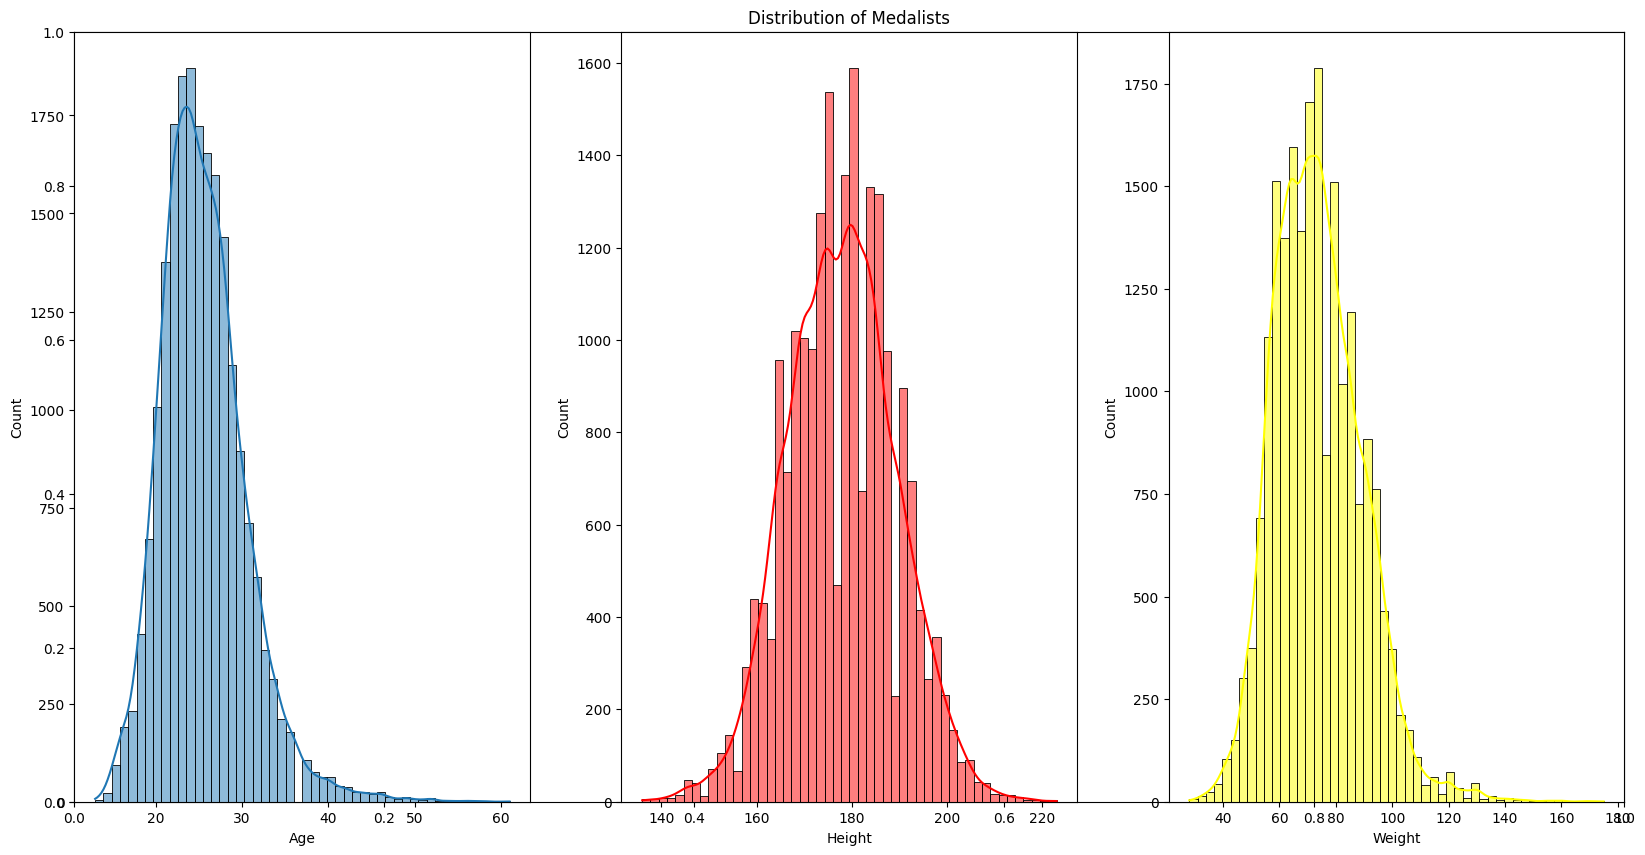

In [91]:
# Correlation with Medaling by age, height, weight
Medalists = data[data['Medal'] == 1]

plt.figure(figsize=(20, 10))
plt.title('Distribution of Medalists')
plt.subplot(1, 3, 1)
sns.histplot(Medalists['Age'], kde=True, bins=50)
plt.subplot(1, 3, 2)
sns.histplot(Medalists['Height'], kde=True, bins=50, color='red')
plt.subplot(1, 3, 3)
sns.histplot(Medalists['Weight'], kde=True, bins=50, color='yellow')
plt.show()

In [92]:
# Medal summary
data['Medal'].value_counts()

,count
Medal,
0,124155
1,20811


# **Univariate Analysis**

**Distribution between sex and medaling**

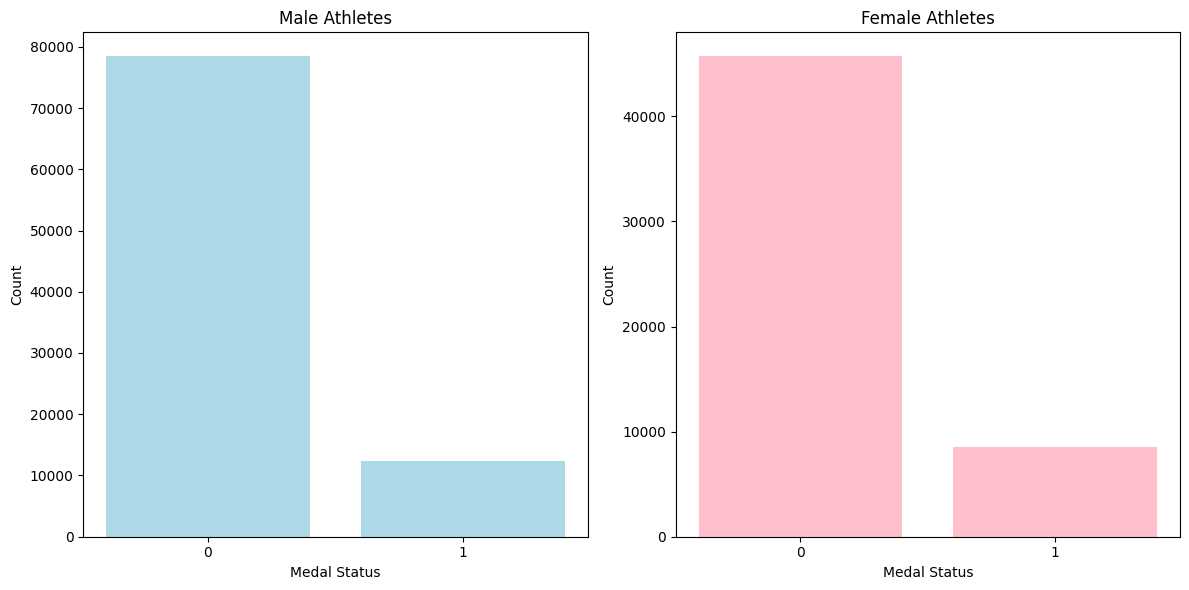

In [93]:
#bar graph by sex and medal
male_data = data[data['Sex'] == 'M']
male_medal_counts = male_data['Medal'].value_counts()

female_data = data[data['Sex'] == 'F']
female_medal_counts = female_data['Medal'].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # Adjust the figsize as needed
axs[0].bar(male_medal_counts.index, male_medal_counts.values, color='lightblue')  # Adjust the color as needed
axs[0].set_title('Male Athletes')
axs[0].set_xlabel('Medal Status')
axs[0].set_ylabel('Count')
axs[0].set_xticks([1, 0])
axs[0].set_xticklabels(['1', '0'], rotation=0)
axs[1].bar(female_medal_counts.index, female_medal_counts.values, color='pink')  # Adjust the color as needed
axs[1].set_title('Female Athletes')
axs[1].set_xlabel('Medal Status')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['0', '1'], rotation=0)
plt.tight_layout()
plt.show()

**Distribution between attributes and medaling**

/tmp/ipykernel_7049/2759451035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Age', data=data, palette='cool')


Medal
0    25.129685
1    25.580558
Name: Age, dtype: float64


/tmp/ipykernel_7049/2759451035.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Height', data=data, palette='cool')


Medal
0    175.384713
1    177.887031
Name: Height, dtype: float64


/tmp/ipykernel_7049/2759451035.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Weight', data=data, palette='cool')


Medal
0    70.319234
1    73.724929
Name: Weight, dtype: float64


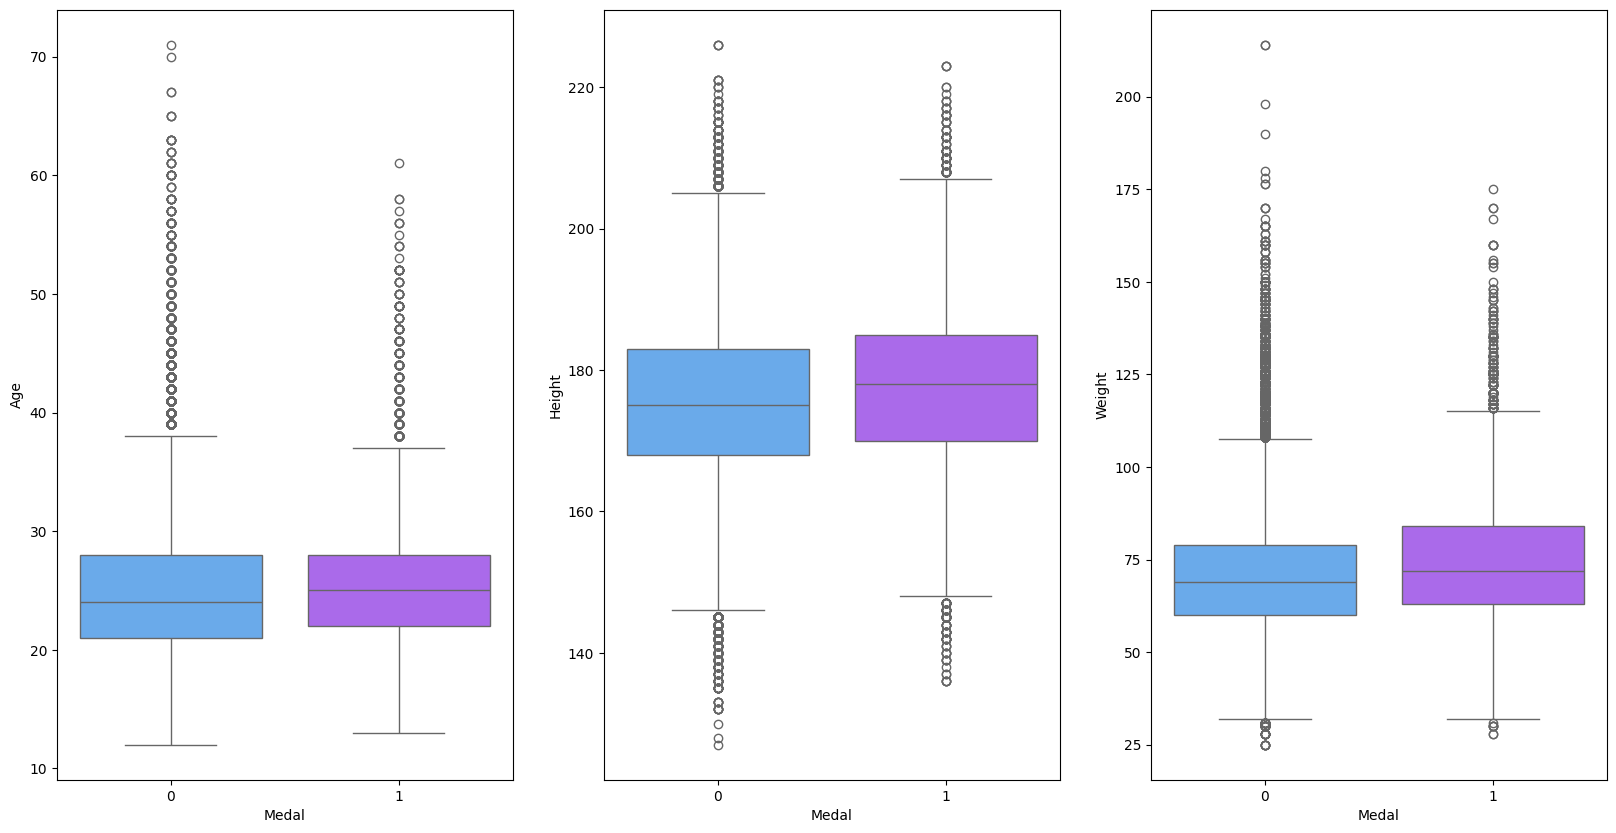

In [94]:
# Medalists by age, height, weight
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
sns.boxplot(x='Medal', y='Age', data=data, palette='cool')
mean_age = data.groupby("Medal")['Age'].mean()
print(mean_age)
plt.subplot(1, 3, 2)
sns.boxplot(x='Medal', y='Height', data=data, palette='cool')
mean_height = data.groupby("Medal")['Height'].mean()
print(mean_height)
plt.subplot(1, 3, 3)
sns.boxplot(x='Medal', y='Weight', data=data, palette='cool')
mean_weight = data.groupby("Medal")['Weight'].mean()
print(mean_weight)
plt.show()

Frequency of Team (top 50)

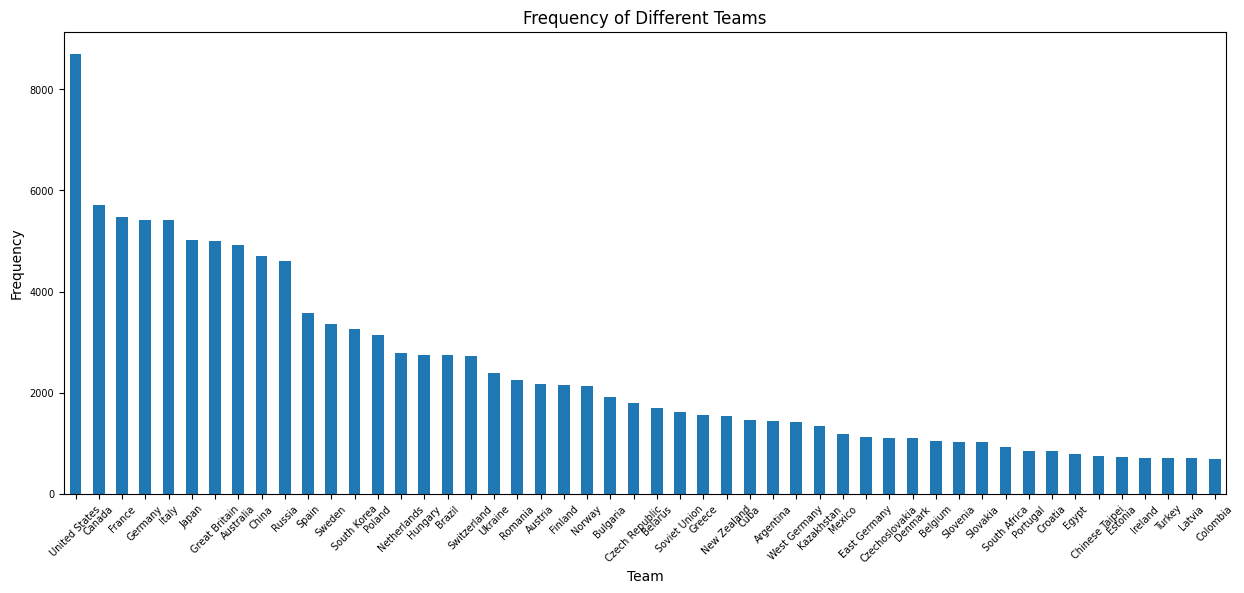

In [95]:
team_counts = data['Team'].value_counts()
team_counts = team_counts.head(50)
plt.figure(figsize=(15, 6))  # Adjust the figure size as needed
team_counts.plot(kind='bar', fontsize=7)
plt.title('Frequency of Different Teams')
plt.xlabel('Team')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.show()

# **Bivariate Analysis**

**Two-Way Table by Sex**

In [96]:
avBySex = data[['Sex', 'Medal', 'Height', 'Weight','Age']]
result = avBySex.groupby(['Sex', 'Medal']).mean().astype(int)
result

Height  Weight  Age
Sex Medal                     
F   0         167      59   24
    1         171      63   24
M   0         179      76   25
    1         182      80   26

**Scatter Plots Comparing Numeric Variables**

array([[<Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Height', ylabel='Age'>,
        <Axes: xlabel='Weight', ylabel='Age'>],
       [<Axes: xlabel='Age', ylabel='Height'>,
        <Axes: xlabel='Height', ylabel='Height'>,
        <Axes: xlabel='Weight', ylabel='Height'>],
       [<Axes: xlabel='Age', ylabel='Weight'>,
        <Axes: xlabel='Height', ylabel='Weight'>,
        <Axes: xlabel='Weight', ylabel='Weight'>]], dtype=object)

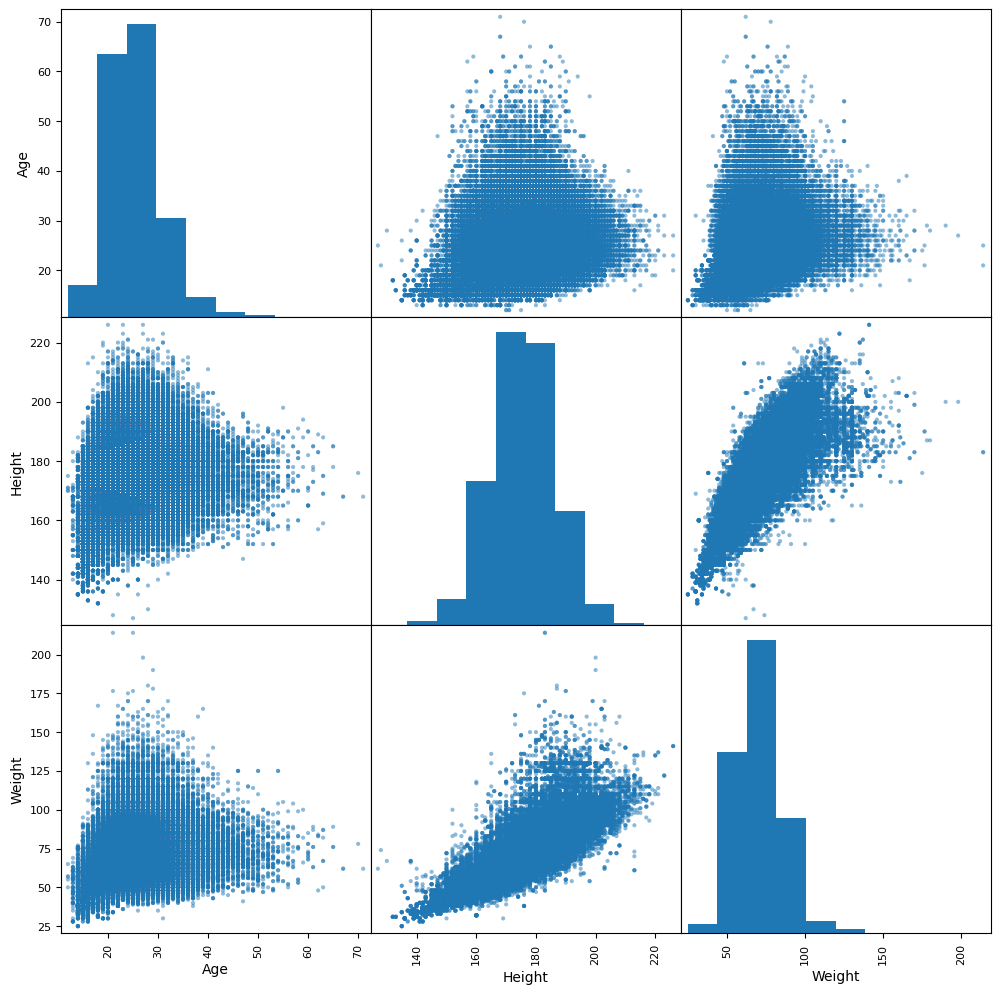

In [97]:
#Scatter plot matrix
noMedal = data[['Age','Height','Weight']]
pd.plotting.scatter_matrix(noMedal, alpha=0.5, figsize=(12, 12), ax=None, grid=False, diagonal='hist', marker='.', density_kwds=None, hist_kwds=None, range_padding=0.05,)

**Bar Graph of Teams (Countries)**

In [98]:
#creating dummy variables
team_medals = data.groupby('Team')['Medal'].sum().reset_index()
#rank
team_medals['Rank'] = team_medals['Medal'].rank(ascending=False, method='min')
#dictionary
team_rank_map = dict(zip(team_medals['Team'], team_medals['Rank']))
#create numeric column
data['TeamNumeric'] = data['Team'].map(team_rank_map)
# data = data.drop(columns=['Team'])
print(data.head())

  Sex   Age  Height  Weight         Team  Medal  TeamNumeric
0   M  24.0   180.0    80.0        China      0          5.0
1   M  23.0   170.0    60.0        China      0          5.0
4   F  21.0   185.0    82.0  Netherlands      0         11.0
5   F  21.0   185.0    82.0  Netherlands      0         11.0
6   F  25.0   185.0    82.0  Netherlands      0         11.0


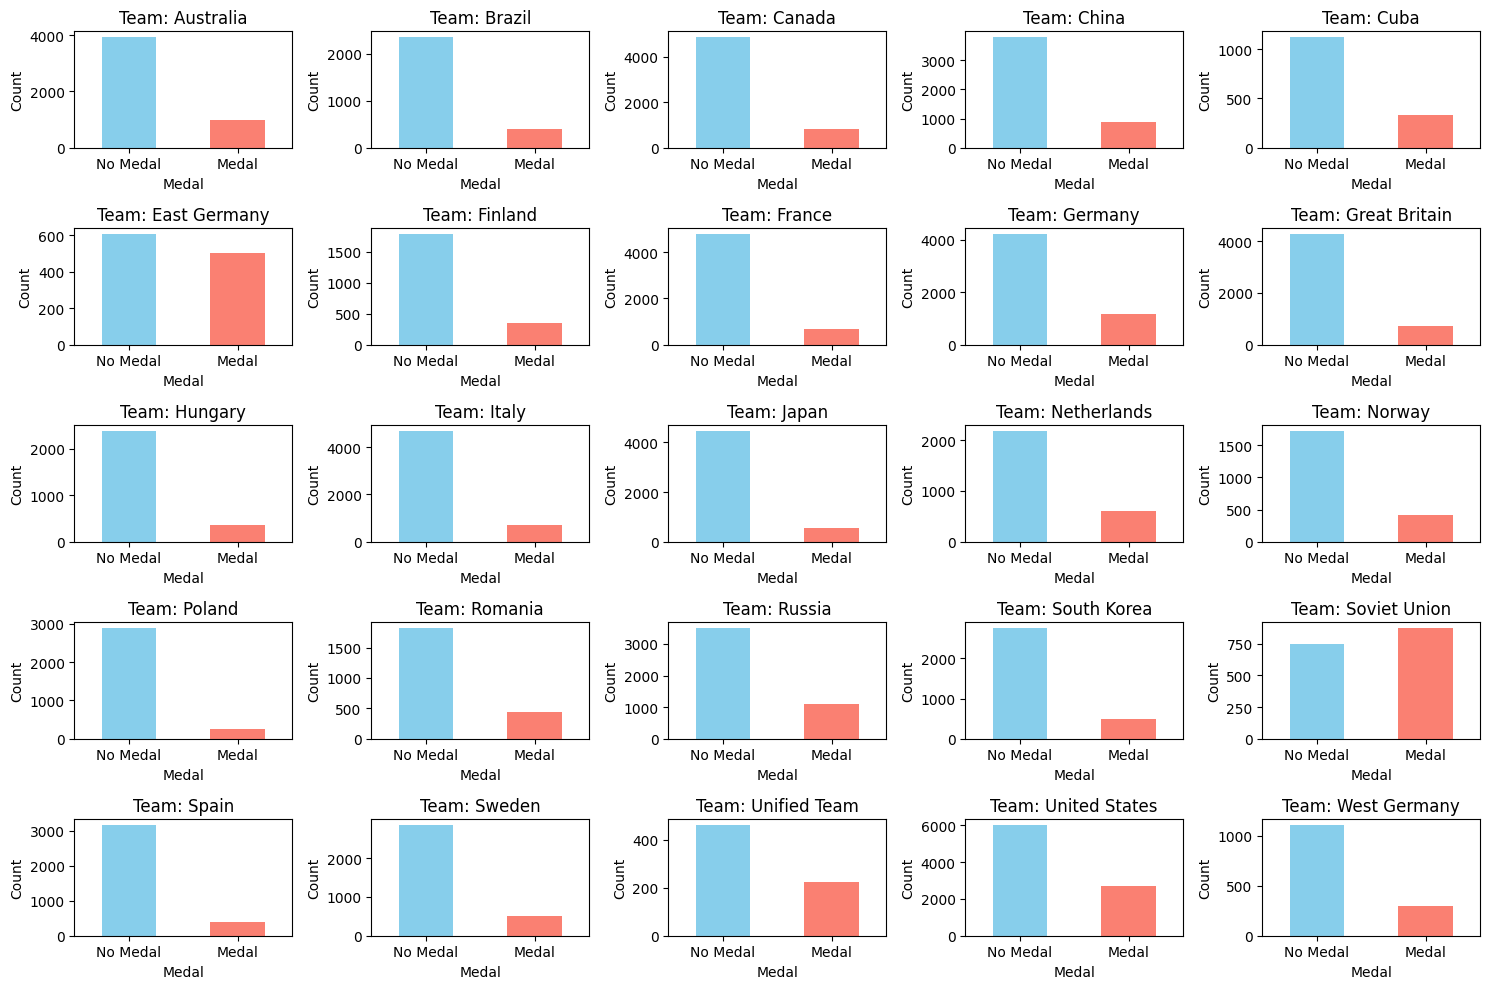

In [99]:
top25 = data[data['TeamNumeric'] <= 25]

grouped = top25.groupby(['Team', 'Medal']).size().unstack(fill_value=0)
# print(grouped)
num_teams = len(grouped)
# print(num_teams)
num_columns = 5
num_rows = (num_teams + num_columns - 1) // num_columns
fig, axs = plt.subplots(num_rows, num_columns, figsize=(num_columns * 3, num_rows * 2))
axs = axs.flatten()
for (team, counts), ax in zip(grouped.iterrows(), axs):
    counts.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'])
    ax.set_title(f'Team: {team}')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['No Medal', 'Medal'], rotation=0)
for i in range(len(grouped), num_rows * num_columns):
    axs[i].set_visible(False)
plt.tight_layout()
plt.show()
#NOTE: teams that are tied have the same ranking which is why there are more than 25 teams below


# **Predictive Models**

In [100]:
data = data.drop(columns = ['Team'])
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 144966 entries, 0 to 271115
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Sex          144966 non-null  object 
 1   Age          144966 non-null  float64
 2   Height       144966 non-null  float64
 3   Weight       144966 non-null  float64
 4   Medal        144966 non-null  int64  
 5   TeamNumeric  144966 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 7.7+ MB
None


In [101]:
#dummy variable for sex
sex_mapping = {'M': 0, 'F': 1}
data['SexNumeric'] = data['Sex'].map(sex_mapping)
data = data.drop(columns=['Sex'])
print(data.head())

    Age  Height  Weight  Medal  TeamNumeric  SexNumeric
0  24.0   180.0    80.0      0          5.0           0
1  23.0   170.0    60.0      0          5.0           0
4  21.0   185.0    82.0      0         11.0           1
5  21.0   185.0    82.0      0         11.0           1
6  25.0   185.0    82.0      0         11.0           1


In [102]:
y=data['Medal'].values
X=data.drop(['Medal'], axis=1).values

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [104]:
#Feature and data scaling
scaler=MinMaxScaler()
train_x=scaler.fit_transform(train_x)
test_x=scaler.transform(test_x)

In [105]:
# Logistic Regression

logistic = 'LogisticRegression'
lr=LogisticRegression(random_state=1, max_iter=1000, class_weight = 'balanced')
lr.fit(train_x, train_y)
lr_predict=lr.predict(test_x)
lr_matrix=confusion_matrix(test_y, lr_predict)
lr_accuracy=accuracy_score(test_y, lr_predict)
print(f"Confusion Matrix {lr_matrix}")
print("Accuracy:", round(lr_accuracy*100, 2), '\n')
print(classification_report(test_y, lr_predict))

Confusion Matrix [[26504 23257]
 [ 2273  5953]]
Accuracy: 55.97 

              precision    recall  f1-score   support

           0       0.92      0.53      0.67     49761
           1       0.20      0.72      0.32      8226

    accuracy                           0.56     57987
   macro avg       0.56      0.63      0.50     57987
weighted avg       0.82      0.56      0.62     57987



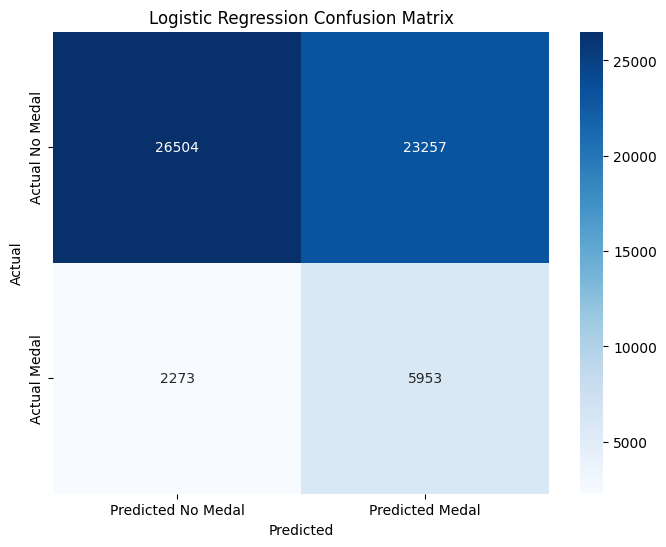

In [106]:
lr_matrix = confusion_matrix(test_y, lr_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(lr_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


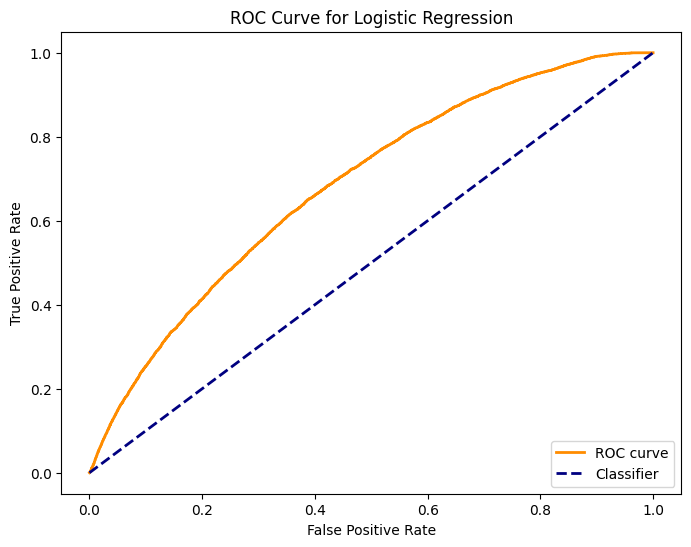

In [107]:
#Calculate ROC Curve

lr_probs = lr.predict_proba(test_x)[:, 1]

fpr, tpr, thresholds = roc_curve(test_y, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, label='Classifier', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.show()


In [108]:
# Decision Tree

decisiontree = 'DecisionTreeClassifier'
tree = DecisionTreeClassifier(criterion='entropy', random_state=10, max_depth=3, class_weight='balanced')
tree.fit(train_x, train_y)
tree_predict=tree.predict(test_x)
tree_matrix=confusion_matrix(test_y, tree_predict)
tree_accuracy=accuracy_score(test_y, tree_predict)
print("Confusion Matrix")
print(tree_matrix)
print("\n")
print("Accuracy of Decision Tree Classifier:", round(tree_accuracy*100, 2), "\n")
print(classification_report(test_y, tree_predict))

Confusion Matrix
[[31547 18214]
 [ 3094  5132]]


Accuracy of Decision Tree Classifier: 63.25 

              precision    recall  f1-score   support

           0       0.91      0.63      0.75     49761
           1       0.22      0.62      0.33      8226

    accuracy                           0.63     57987
   macro avg       0.57      0.63      0.54     57987
weighted avg       0.81      0.63      0.69     57987



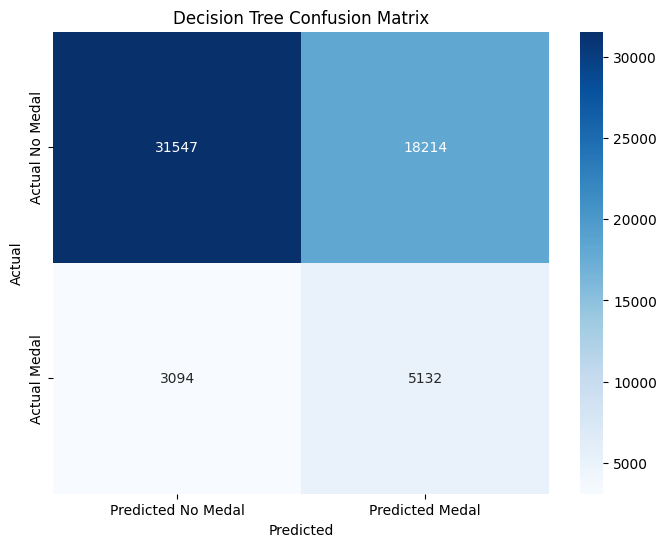

In [109]:
tree_matrix = confusion_matrix(test_y, tree_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(tree_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

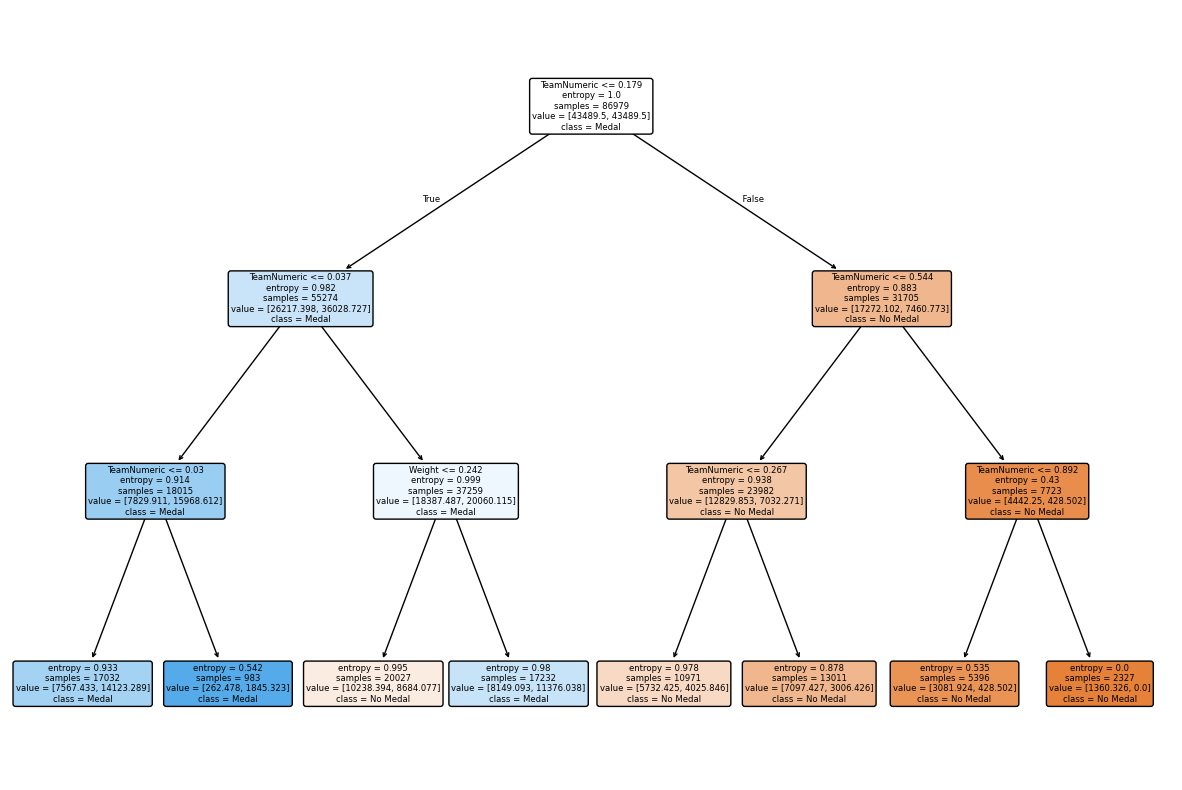

In [110]:
plt.figure(figsize=(15, 10))
plot_tree(tree, feature_names=data.drop(['Medal'], axis=1).columns, class_names=['No Medal', 'Medal'], filled=True, rounded=True)
plt.show()


In [112]:
# Naive Bayes

bayes = 'NaiveBayes'
naivebayes = GaussianNB(priors=[0.5, 0.5])
naivebayes.fit(train_x, train_y)
naivebayes_predict=naivebayes.predict(test_x)
naivebayes_matrix=confusion_matrix(test_y, naivebayes_predict)
naivebayes_accuracy=accuracy_score(test_y, naivebayes_predict)
print("Confusion Matrix")
print(naivebayes_matrix, '\n')
print("Accuracy of Naive Bayes: ", round(naivebayes_accuracy*100, 2), '\n')
print(classification_report(test_y, naivebayes_predict))

Confusion Matrix
[[16494 33267]
 [  972  7254]] 

Accuracy of Naive Bayes:  40.95 

              precision    recall  f1-score   support

           0       0.94      0.33      0.49     49761
           1       0.18      0.88      0.30      8226

    accuracy                           0.41     57987
   macro avg       0.56      0.61      0.39     57987
weighted avg       0.84      0.41      0.46     57987



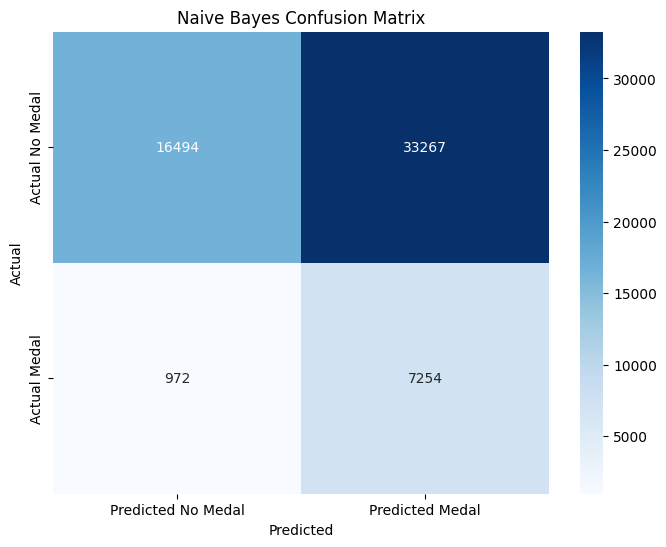

In [113]:
naivebayes_matrix = confusion_matrix(test_y, naivebayes_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(naivebayes_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

**Which model is a better fit for the data?**

In [114]:
model = pd.DataFrame({'Model': ['Logistic Regression', 'Decision Tree', 'Gaussian NB'],
                      'Accuracy': [round(lr_accuracy*100, 2), round(tree_accuracy*100, 2), round(naivebayes_accuracy*100, 2)]})
model

,Model,Accuracy
0,Logistic Regression,55.97
1,Decision Tree,63.25
2,Naive Bayes,40.95


#**Results**

In [119]:

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Naive Bayes'],
    'Accuracy': [round(lr_accuracy*100, 2), round(tree_accuracy*100, 2), round(naivebayes_accuracy*100, 2)],
    'Medal Recall': [
        round(recall_score(test_y, lr_predict), 2),
        round(recall_score(test_y, tree_predict), 2),
        round(recall_score(test_y, naivebayes_predict), 2)
    ],
    'Medal Precision': [
        round(precision_score(test_y, lr_predict), 2),
        round(precision_score(test_y, tree_predict), 2),
        round(precision_score(test_y, naivebayes_predict), 2)
    ],
    'Medal F1': [
        round(f1_score(test_y, lr_predict), 2),
        round(f1_score(test_y, tree_predict), 2),
        round(f1_score(test_y, naivebayes_predict), 2)
    ]
})
results

,Model,Accuracy,Medal Recall,Medal Precision,Medal F1
0,Logistic Regression,55.97,0.72,0.20,0.32
1,Decision Tree,63.25,0.62,0.22,0.33
2,Naive Bayes,40.95,0.88,0.18,0.30


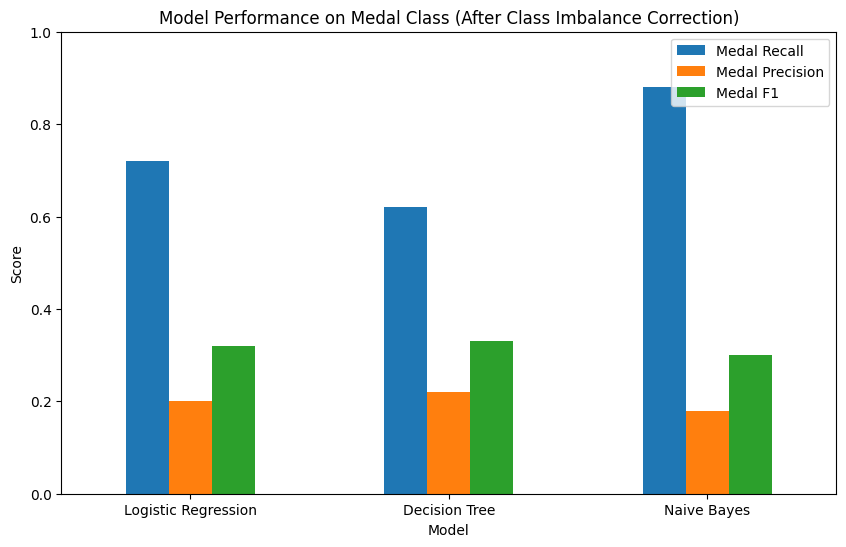

In [120]:
metrics = results.set_index('Model')[['Medal Recall', 'Medal Precision', 'Medal F1']]

ax = metrics.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Model Performance on Medal Class (After Class Imbalance Correction)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

After correcting for class imbalance, all three models traded overall accuracy for meaningfully better recall on the medal class:

- **Naive Bayes** achieved the highest recall (0.88), correctly identifying the most actual medalists, but at the cost of the lowest precision (0.18) and lowest accuracy (40.95%).
- **Decision Tree** offered the most balanced tradeoff, with 63.25% accuracy and solid recall (0.62) and precision (0.22).
- **Logistic Regression** landed in between, with 0.72 recall and the lowest overall variance between metrics.

